In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
data1=pd.read_csv('/content/fiat500.csv')

In [51]:
data1.shape

(1520, 9)

In [52]:
data1.head()

,ID,model,engine_power,age_in_days,km,previous_owners,lat,lon,price
0,1,lounge,51,882,25000,1,44.907242,8.611560,8900
1,2,pop,51,1186,32500,1,45.666359,12.241890,8800
2,3,sport,74,4658,142228,1,45.503300,11.417840,4200
3,4,lounge,51,2739,160000,1,40.633171,17.634609,6000
4,5,pop,73,3074,106880,1,41.903221,12.495650,5700


In [53]:
data1.isnull().count()

,0
ID,1520
model,1520
engine_power,1520
age_in_days,1520
km,1520
previous_owners,1520
lat,1520
lon,1520
price,1520


In [54]:
data1.describe()

,ID,engine_power,age_in_days,km,previous_owners,lat,lon,price
count,1520.000000,1520.000000,1520.000000,1520.000000,1520.000000,1520.000000,1520.000000,1520.000000
mean,768.854605,51.915132,1657.190789,53602.474342,1.123684,43.539485,11.571552,8564.311842
std,443.599478,4.010360,1290.870689,40181.202940,0.415901,2.137960,2.332344,1942.771619
min,1.000000,51.000000,366.000000,1232.000000,1.000000,36.855839,7.245400,2500.000000
25%,383.750000,51.000000,670.000000,20000.000000,1.000000,41.794763,9.505090,7100.000000
50%,769.500000,51.000000,1066.000000,39162.000000,1.000000,44.394096,11.869260,9000.000000
75%,1151.250000,51.000000,2623.750000,80000.000000,1.000000,45.467960,12.786127,10000.000000
max,1538.000000,77.000000,4658.000000,235000.000000,4.000000,46.795612,18.365520,11100.000000


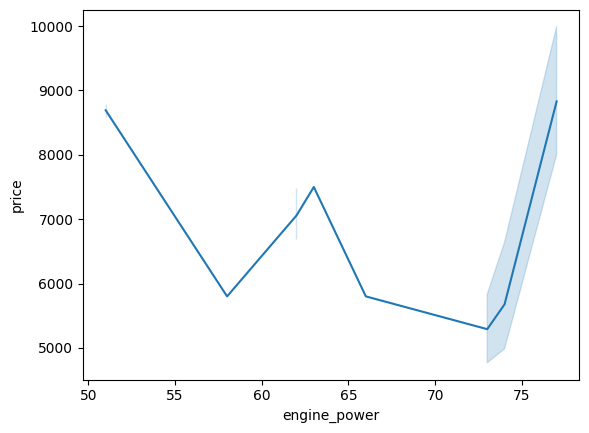

In [55]:
sns.lineplot(x='engine_power',y='price',data=data1)
plt.show()

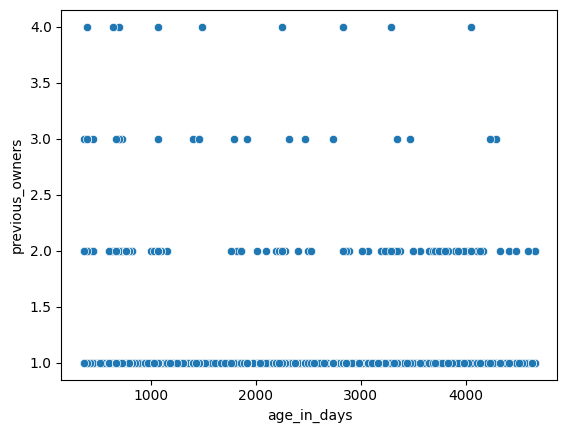

In [56]:
sns.scatterplot(x='age_in_days',y='previous_owners',data=data1)
plt.show()

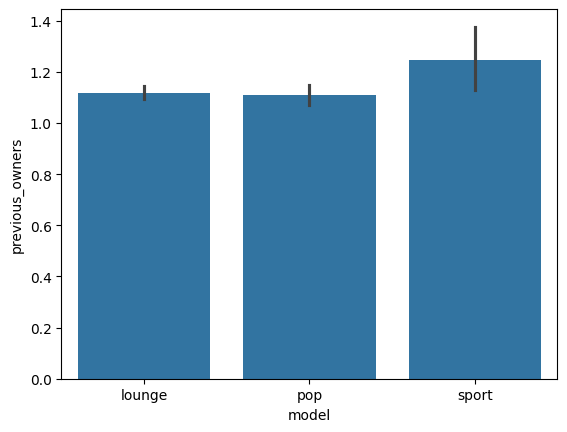

In [57]:
sns.barplot(x='model',y='previous_owners',data=data1)
plt.show()

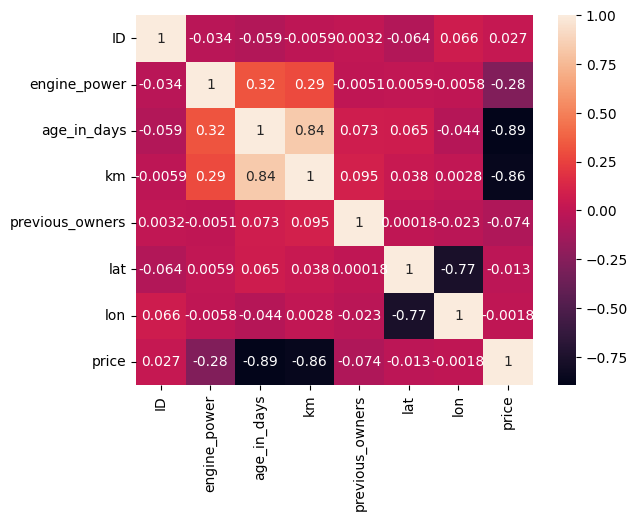

In [58]:
data1.corr(numeric_only=True)
sns.heatmap(
    data1.corr(numeric_only=True),
    annot=True)
plt.show()

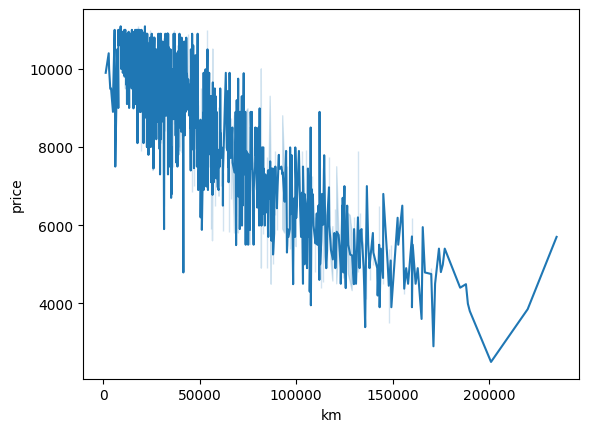

In [59]:
sns.lineplot(x='km',y='price',data=data1)
plt.show()

In [60]:
x=data1.drop(['price'],axis=1)
y=data1['price']


In [61]:
x.head()

,ID,model,engine_power,age_in_days,km,previous_owners,lat,lon
0,1,lounge,51,882,25000,1,44.907242,8.611560
1,2,pop,51,1186,32500,1,45.666359,12.241890
2,3,sport,74,4658,142228,1,45.503300,11.417840
3,4,lounge,51,2739,160000,1,40.633171,17.634609
4,5,pop,73,3074,106880,1,41.903221,12.495650


In [62]:
y.head()

,price
0,8900
1,8800
2,4200
3,6000
4,5700


In [63]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=45)

In [64]:
x_train.head()

,ID,model,engine_power,age_in_days,km,previous_owners,lat,lon
384,388,lounge,51,731,33280,2,40.752209,14.45341
538,545,lounge,51,3166,72185,1,45.763969,9.10698
639,647,lounge,51,821,33725,1,45.598598,9.16404
1349,1365,lounge,51,2466,78000,1,43.463539,11.87765
182,186,lounge,51,487,18337,1,39.331760,16.18133


In [65]:
y_train.head()

,price
384,9980
538,6500
639,9890
1349,7900
182,10500


In [66]:
x_test.head()

,ID,model,engine_power,age_in_days,km,previous_owners,lat,lon
1128,1140,pop,51,3804,110000,1,45.776588,12.04730
731,741,lounge,51,640,23951,2,44.283878,11.88814
1011,1022,lounge,51,4200,110000,1,41.903221,12.49565
228,232,lounge,51,670,25000,1,45.078899,9.30230
1062,1073,lounge,51,2647,70000,1,43.521301,11.56849


In [67]:
y_test.head()

,price
1128,3900
731,9790
1011,4999
228,10500
1062,7500


In [68]:
data1.groupby(['model']).count()

,ID,engine_power,age_in_days,km,previous_owners,lat,lon,price
model,,,,,,,,
lounge,1079,1079,1079,1079,1079,1079,1079,1079
pop,356,356,356,356,356,356,356,356
sport,85,85,85,85,85,85,85,85


<Axes: >

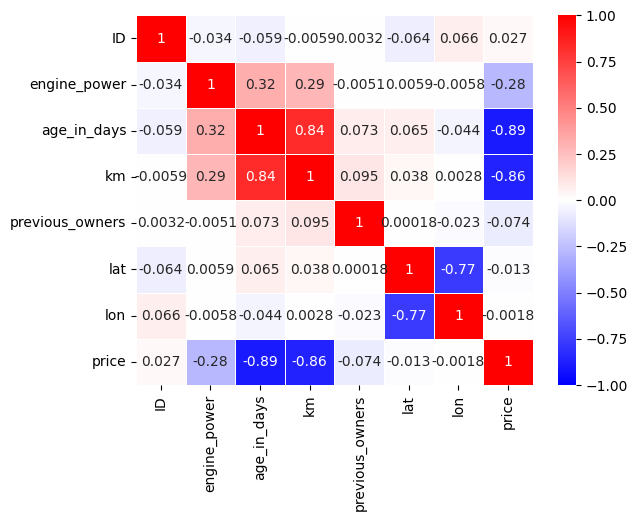

In [69]:
cor_mat = data1.corr(numeric_only=True)
sns.heatmap(cor_mat,vmax=1,vmin=-1,annot=True,linewidths=.5,cmap='bwr')

In [70]:
data1=pd.get_dummies(data1,dtype=int)

In [71]:
data1 = data1.drop(columns=['lon','lat','ID'], errors='ignore')

In [72]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [73]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Re-define x and y from the now one-hot encoded data1
x = data1.drop(['price'], axis=1)
y = data1['price']

# Re-run train_test_split to get updated x_train, y_train
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=45)

reg=LinearRegression()
reg.fit(x_train,y_train)

LinearRegression()

In [74]:
ypred=reg.predict(x_test)

In [75]:
from sklearn.metrics import r2_score
r2_score(y_test,ypred)

0.8217808597856759

In [76]:
from sklearn.metrics import mean_absolute_error as mape
mape_value=mape(y_test,ypred)
mape_value

608.1862133783758

In [77]:
from sklearn.metrics import mean_squared_error
t=mean_squared_error(y_test,ypred)
print(t**.5)

820.4224318737554


In [78]:
new = [[51,2197,70000,1,1,0,0],[51,3127,100000,1,1,0,0],[51,5227,175000,1,1,0,0]]
price=reg.predict(new)
price

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([7852.51020872, 6499.54970593, 3320.61509603])

In [79]:
Results=pd.DataFrame(columns=['price','predicted'])
Results['price']=y_test
Results['predicted']=ypred
Results=Results.reset_index()
Results['Id']=Results.index
Results.head(10)


,index,price,predicted,Id
0,1128,3900,5439.781360,0
1,731,9790,10040.351905,1
2,1011,4999,5358.584864,2
3,228,10500,10001.318063,3
4,1062,7500,7445.576915,4
5,415,9450,9631.734484,5
6,1358,8980,9713.456258,6
7,160,9000,9299.300001,7
8,1049,5700,4700.267006,8
9,13,4800,5241.093168,9


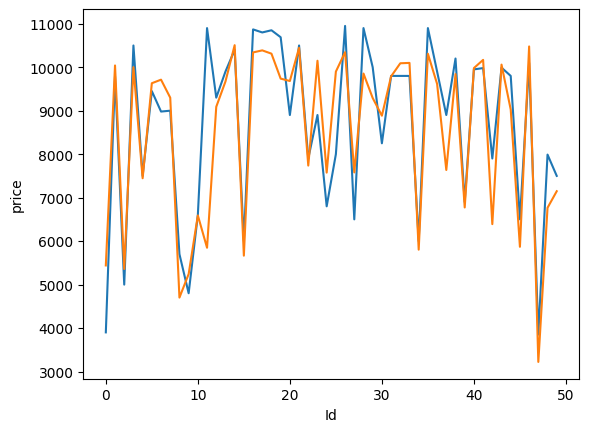

In [80]:
import seaborn as sns
sns.lineplot(x='Id',y='price',data=Results.head(50))
sns.lineplot(x='Id',y='predicted',data=Results.head(50))
plt.show()

In [81]:
from sklearn.model_selection import  GridSearchCV

In [82]:
from sklearn.linear_model import Ridge

In [83]:
alpha=[1e-15,1e-10,1e-8,1e-4,1e-3,1e-2,1,5,10,20,30]
ridge=Ridge()
parameters={'alpha':alpha}
ridge_regressor=GridSearchCV(ridge,parameters)
ridge_regressor.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.80028e-25): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.06247e-25): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=6.31641e-23): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=6.36709e-23): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=6.30631e-23): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/pytho

GridSearchCV(estimator=Ridge(),
             param_grid={'alpha': [1e-15, 1e-10, 1e-08, 0.0001, 0.001, 0.01, 1,
                                   5, 10, 20, 30]})

In [84]:
ridge_regressor.best_params_

{'alpha': 30}

In [85]:
alpha

[1e-15, 1e-10, 1e-08, 0.0001, 0.001, 0.01, 1, 5, 10, 20, 30]

In [86]:
ridge=Ridge(alpha=30)
ridge.fit(x_train,y_train)
y_pred_ridge=ridge.predict(x_test)

In [87]:
from sklearn .metrics import r2_score
r2_score(y_test,y_pred_ridge)

0.8215469628822509

In [88]:
from sklearn.metrics import mean_absolute_error as mape
mape_value=mape(y_test,y_pred_ridge)
mape_value

609.2420744158209

In [89]:
from sklearn.metrics import mean_squared_error
t=mean_squared_error(y_test,y_pred_ridge)
print(t**.5)

820.9606213922647


In [90]:
from sklearn.model_selection import GridSearchCV #GridSearchCV is for parameter tuning
from sklearn.ensemble import RandomForestRegressor
reg=RandomForestRegressor()
n_estimators=[25,50,75,100,125,150,175,200] #number of decision trees in the forest, default = 100
criterion=['squared_error'] #criteria for choosing nodes default = 'gini'
max_depth=[3,5,10] #maximum number of nodes in a tree default = None (it will go till all possible nodes)
parameters={'n_estimators': n_estimators,'criterion':criterion,'max_depth':max_depth}
RFC_reg = GridSearchCV(reg, parameters)
RFC_reg.fit(x_train,y_train)

GridSearchCV(estimator=RandomForestRegressor(),
             param_grid={'criterion': ['squared_error'],
                         'max_depth': [3, 5, 10],
                         'n_estimators': [25, 50, 75, 100, 125, 150, 175, 200]})

In [91]:
RFC_reg.best_params_

{'criterion': 'squared_error', 'max_depth': 5, 'n_estimators': 175}

In [93]:
ypred=RFC_reg.predict(x_test)

In [96]:
reg.fit(x_train,y_train)

RandomForestRegressor()

In [97]:
ypred=reg.predict(x_test)

In [98]:
ypred

array([ 5399.37      ,  9594.85      ,  5037.08      , 10102.5       ,
        6970.4       , 10088.18166667,  9109.78666667,  9105.2       ,
        4866.59      ,  4868.82      ,  7099.61      ,  5051.4       ,
        9388.4       ,  9966.74      , 10101.95      ,  5748.        ,
       10602.8       , 10415.7       , 10695.6       ,  9129.671     ,
        9949.6       , 10781.5       ,  7745.        , 10276.15      ,
        7971.2       ,  9688.2       , 10311.7       ,  7822.5       ,
        9779.03333333,  9761.8       ,  8600.9       ,  9353.786     ,
        9663.2       , 10061.59      ,  5460.        , 10577.3       ,
        9658.75      ,  7809.77      ,  9517.3       ,  7639.1       ,
       10029.7       , 10115.        ,  6277.7       , 10026.775     ,
        9150.69666667,  5536.95      , 10599.35      ,  3531.1       ,
        6445.13      ,  7086.93      ,  6653.73      , 10225.9       ,
        7624.8       ,  5001.38      ,  9561.89      ,  7505.5       ,
      

In [92]:
from sklearn.metrics import r2_score
r2_score(y_test,ypred)

0.8217808597856759

In [99]:
from sklearn.metrics import mean_absolute_error as mape
mape_value=mape(y_test,ypred)
mape_value

620.2325623908255